In [ ]:
import pandas as pd
import numpy as np
import itertools
import random
from pathlib import Path
from typing import Tuple, List, Dict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
from google.colab import files
files.upload()

Saving config.py to config.py
Saving lstm_ptf.py to lstm_ptf.py


{'config.py': b'from pathlib import Path\r\nimport torch\r\n\r\nDATA_FOLDER = Path("/content/sample_data/lstm/")\r\nASSETS, TIMEFRAMES = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "XRPUSDT", "BNBUSDT", "DOGEUSDT", "DOTUSDT", "LINKUSDT", "UNIUSDT",\r\n            "LTCUSDT", "AAVEUSDT", "TRXUSDT", "AGLDUSDT", "AVAXUSDT", "XTZUSDT"], ["1d", "1h", "15m"]\r\n\r\nLOOKBACK_DAYS, LOOKBACK_HOURS, LOOKBACK_15MIN = 14, 3 * 24, 3 * 24 * 4\r\nTRAIN_START, TRAIN_END, TEST_START, TEST_END = "2024-01-01", "2025-10-31", "2025-11-01", "2026-01-31"\r\n\r\nDEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")\r\n\r\nDATA_PATH = Path("/content/sample_data/lstm/multi_freq_dataset.npz")\r\n# Model hyperparams (reasonable starting point \xe2\x80\x94 paper uses something similar)\r\nINPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT   = len(ASSETS), 128, 2, 0.0\r\nLR, WEIGHT_DECAY, EPOCHS = 3e-4, 1e-5, 50 # light L2\r\n# Log-MDD hyperparameters\r\nTAU = 0.1\r\nEPS_MDD = 1e-6\r\nlambda_return = 0.8',
 'lstm_pt

In [ ]:
from lstm_ptf import load_and_prepare_df, get_data_dict, build_windows, scores_to_weights, save_data, portfolio_return, MultiFreqLSTM, compute_pnl_and_cumulative, compute_maximum_drawdown, evaluate_full_period, log_mdd_loss

In [ ]:
DATA_FOLDER = "/content/sample_data/lstm"
DATA_PATH = "/content/sample_data/lstm/multi_freq_dataset.npz"

ASSETS, TIMEFRAMES = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "XRPUSDT", "BNBUSDT", "DOGEUSDT", "DOTUSDT", "LINKUSDT", "UNIUSDT",
            "LTCUSDT", "AAVEUSDT", "TRXUSDT", "AGLDUSDT", "AVAXUSDT", "XTZUSDT"], ["1d", "1h", "15m"]
LOOKBACK_DAYS, LOOKBACK_HOURS, LOOKBACK_15MIN = 14, 3 * 24, 3 * 24 * 4
TRAIN_START, TRAIN_END, TEST_START, TEST_END = "2023-07-01", "2025-08-31", "2025-09-01", "2025-10-30"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT   = len(ASSETS), 48, 2, 0.1
LR, WEIGHT_DECAY, EPOCHS = 1e-5, 1e-3, 150
# Log-MDD hyperparameters
TAU = 1.0
EPS_MDD = 1e-6
lambda_return = 0.0

### Part 1

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU

    # Make CuDNN deterministic (warning: may reduce performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Python hash seed
    import os
    os.environ['PYTHONHASHSEED'] = str(seed)

# Call this BEFORE any model/data operations
set_seed(42)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [ ]:
set_seed(42)
g = torch.Generator()
g.manual_seed(42)
save_data("/content/sample_data/lstm/multi_freq_dataset.npz", TRAIN_START, TRAIN_END, TEST_START, TEST_END)

In [ ]:
# ── Load data ────────────────────────────────────────
print("Loading dataset...")
data = np.load(DATA_PATH)
X_train = torch.from_numpy(data["X_train"]).float().to(DEVICE)
y_train = torch.from_numpy(data["y_train"]).float().to(DEVICE)
X_test  = torch.from_numpy(data["X_test"]).float().to(DEVICE)
y_test  = torch.from_numpy(data["y_test"]).float().to(DEVICE)
BATCH_SIZE = len(X_train)

print(f"X_train: {X_train.shape},  y_train: {y_train.shape}")

train_ds = TensorDataset(X_train, y_train)
# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=g
)

model = MultiFreqLSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

Loading dataset...
X_train: torch.Size([778, 374, 15]),  y_train: torch.Size([778, 15])


### Grid Search

In [ ]:
search_space = {
    'dropout':     [0.1],
    'weight_decay': [1e-3], # 1e-2
    'num_layers': [2], # 1e-2
    'lr':          [5e-5, 1e-4, 1.5e-4],
    'lambda_return': [0.0],
    'tau':         [0.25],
    'hidden_size': [80, 64],
    'epochs': [300],
}

# ────────────────────────────────────────────────
for params in itertools.product(*search_space.values()):
    dropout, weight_decay, num_layers, lr, lambda_return, tau, hidden_size, epochs = params
    config = dict(zip(search_space.keys(), params))
    DROPOUT     = config["dropout"]
    WEIGHT_DECAY = config["weight_decay"]
    NUM_LAYERS   = config["num_layers"]
    LR           = config["lr"]
    TAU          = config["tau"]
    LAMBDA_RETURN = config["lambda_return"]
    HIDDEN_SIZE  = config["hidden_size"]
    EPOCHS  = config["epochs"]

    ### MODEL SETUP
    set_seed(42)
    g = torch.Generator()
    g.manual_seed(42)
    # save_data("/content/sample_data/lstm/multi_freq_dataset.npz", TRAIN_START, TRAIN_END, TEST_START, TEST_END)

    X_train = torch.from_numpy(data["X_train"]).float().to(DEVICE)
    y_train = torch.from_numpy(data["y_train"]).float().to(DEVICE)
    X_test  = torch.from_numpy(data["X_test"]).float().to(DEVICE)
    y_test  = torch.from_numpy(data["y_test"]).float().to(DEVICE)
    BATCH_SIZE = len(X_train)
    train_ds = TensorDataset(X_train, y_train)
    # train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        worker_init_fn=seed_worker,
        generator=g
    )

    model = MultiFreqLSTM(
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    ).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


    print(f"Training with: {config}")
    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0.0
        total_batch_pnl = 0.0
        n_batches = 0

        for Xb, yb in train_loader:
            Xb = Xb.to(DEVICE)
            yb = yb.to(DEVICE)

            scores = model(Xb)
            weights = scores_to_weights(scores)
            daily_pnl = (weights * yb).sum(dim=1)
            cum_pnl = daily_pnl.cumsum(dim=0)

            loss = log_mdd_loss(cum_pnl, tau=TAU, eps=EPS_MDD)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_batch_pnl += daily_pnl.mean().item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        avg_batch_pnl = total_batch_pnl / n_batches

        # Evaluate test set
        if epoch == EPOCHS:
            _ = evaluate_full_period(model, X_test, y_test, name=f"Test after epoch {epoch}")

Training with: {'dropout': 0.1, 'weight_decay': 0.001, 'num_layers': 2, 'lr': 5e-05, 'lambda_return': 0.0, 'tau': 0.25, 'hidden_size': 80, 'epochs': 300}

Test after epoch 300 set performance:
──────────────────────────────
Sharpe       : -0.8675 / Max DD       : 0.1847 / Cum PnL      : -0.0805 / Avg Turnover : 0.0016 / ──────────────────────────────

Training with: {'dropout': 0.1, 'weight_decay': 0.001, 'num_layers': 2, 'lr': 5e-05, 'lambda_return': 0.0, 'tau': 0.25, 'hidden_size': 64, 'epochs': 300}

Test after epoch 300 set performance:
──────────────────────────────
Sharpe       : -0.1837 / Max DD       : 0.0933 / Cum PnL      : -0.0124 / Avg Turnover : 0.0022 / ──────────────────────────────

Training with: {'dropout': 0.1, 'weight_decay': 0.001, 'num_layers': 2, 'lr': 0.0001, 'lambda_return': 0.0, 'tau': 0.25, 'hidden_size': 80, 'epochs': 300}

Test after epoch 300 set performance:
──────────────────────────────
Sharpe       : -0.2663 / Max DD       : 0.1187 / Cum PnL      : -0.

### Test

In [ ]:
LR, TAU, LAMBDA_RETURN, HIDDEN_SIZE, EPOCHS = 1.5e-4, 0.25, 0.0, 80, 300

set_seed(42)
g = torch.Generator()
g.manual_seed(42)
save_data("/content/sample_data/lstm/multi_freq_dataset.npz", TRAIN_START, TEST_END, "2025-11-01", "2026-01-31")
data = np.load(DATA_PATH)
X_test  = torch.from_numpy(data["X_test"]).float().to(DEVICE)
y_test  = torch.from_numpy(data["y_test"]).float().to(DEVICE)

model = MultiFreqLSTM(
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    ).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [ ]:
for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0
    total_batch_pnl = 0.0
    n_batches = 0

    for Xb, yb in train_loader:
        Xb = Xb.to(DEVICE)
        yb = yb.to(DEVICE)

        scores = model(Xb)
        weights = scores_to_weights(scores)
        daily_pnl = (weights * yb).sum(dim=1)
        cum_pnl = daily_pnl.cumsum(dim=0)

        loss = log_mdd_loss(cum_pnl, tau=TAU, eps=EPS_MDD)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_batch_pnl += daily_pnl.mean().item()
        n_batches += 1

    avg_loss = total_loss / n_batches
    avg_batch_pnl = total_batch_pnl / n_batches

    if epoch % 50 == 0 or epoch == 150:
        _ = evaluate_full_period(model, X_test, y_test, name=f"Test after epoch {epoch}")

print("\nTraining finished.")


Test after epoch 50 set performance:
──────────────────────────────
Sharpe       : 0.7942 / Max DD       : 0.1692 / Cum PnL      : 0.1150 / Avg Turnover : 0.0016 / ──────────────────────────────


Test after epoch 100 set performance:
──────────────────────────────
Sharpe       : 0.6109 / Max DD       : 0.2460 / Cum PnL      : 0.0915 / Avg Turnover : 0.0017 / ──────────────────────────────


Test after epoch 150 set performance:
──────────────────────────────
Sharpe       : 0.8843 / Max DD       : 0.2324 / Cum PnL      : 0.1301 / Avg Turnover : 0.0018 / ──────────────────────────────


Test after epoch 200 set performance:
──────────────────────────────
Sharpe       : 1.2352 / Max DD       : 0.2171 / Cum PnL      : 0.1811 / Avg Turnover : 0.0021 / ──────────────────────────────


Test after epoch 250 set performance:
──────────────────────────────
Sharpe       : 1.2906 / Max DD       : 0.1882 / Cum PnL      : 0.1840 / Avg Turnover : 0.0018 / ──────────────────────────────


Test after

### plot

In [ ]:
test_dates = pd.date_range(start=TEST_START, end=TEST_END, freq='D')
TEST_START, TEST_END = "2025-11-01", "2026-01-31"

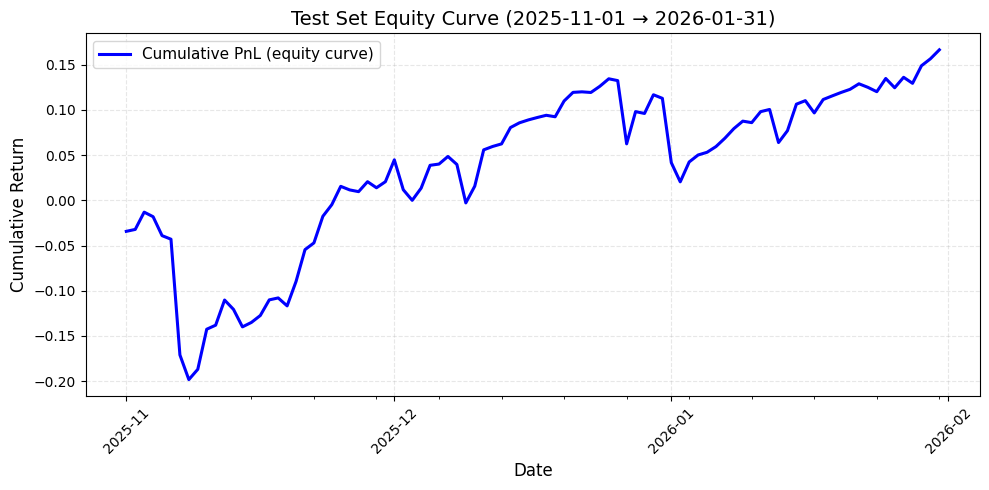

In [ ]:
test_dates = pd.date_range(start=TEST_START, end=TEST_END, freq='D')

with torch.no_grad():
    model.eval()
    scores = model(X_test.to(DEVICE))
    weights = scores_to_weights(scores)
    daily_pnl, cum_pnl = compute_pnl_and_cumulative(weights, y_test.to(DEVICE))

cum_pnl_np = cum_pnl.cpu().numpy()
plt.figure(figsize=(10, 5))
plt.plot(test_dates, cum_pnl_np,
         label='Cumulative PnL (equity curve)',
         color='blue', linewidth=2.2)

plt.title(f'Test Set Equity Curve ({TEST_START} → {TEST_END})', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_minor_locator(mdates.DayLocator(interval=7))
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

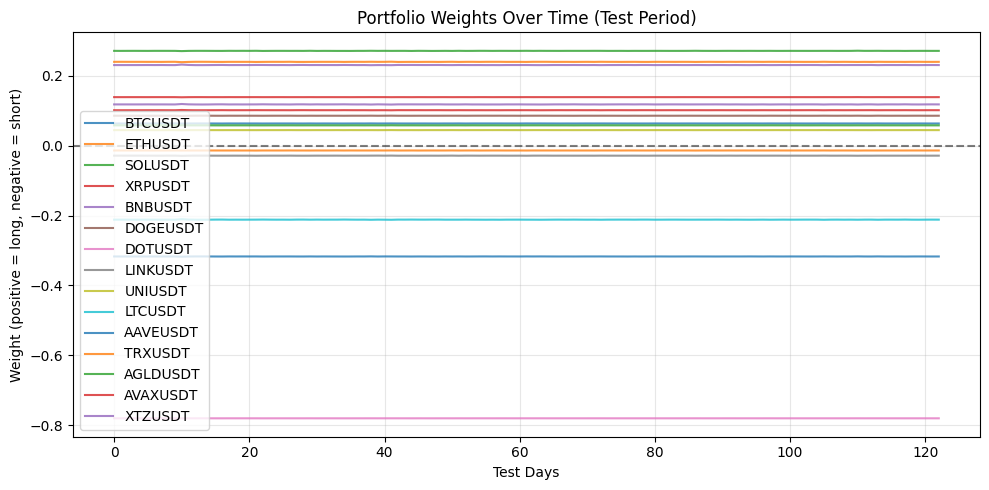


Average weight per asset:
BTCUSDT : -0.3172  ETHUSDT : -0.0138  SOLUSDT : 0.2713  XRPUSDT : 0.1388  BNBUSDT : 0.2307  DOGEUSDT: 0.0856  DOTUSDT : -0.7804  LINKUSDT: -0.0287  UNIUSDT : 0.0444  LTCUSDT : -0.2118  AAVEUSDT: 0.0635  TRXUSDT : 0.2398  AGLDUSDT: 0.0581  AVAXUSDT: 0.1015  XTZUSDT : 0.1181  

In [ ]:
# Weights over time (long/short allocations)
weights_np = weights.cpu().numpy()

# Plot weights for each asset
plt.figure(figsize=(10, 5))
for i, asset in enumerate(ASSETS):
    plt.plot(weights_np[:, i], label=asset, alpha=0.8, linewidth=1.5)

plt.title('Portfolio Weights Over Time (Test Period)')
plt.xlabel('Test Days')
plt.ylabel('Weight (positive = long, negative = short)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

avg_weight = np.mean(weights_np, axis=0)
print("\nAverage weight per asset:")
for asset, w in zip(ASSETS, avg_weight):
    print(f"{asset:8}: {w:.4f}", end="  ")